In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('D:\project_5\DATA\Superstore.csv',encoding='latin1')

In [3]:
# Order count
customer_orders = df.groupby("Customer Name")["Order ID"].count()
customer_orders

Customer Name
Aaron Bergman          6
Aaron Hawkins         11
Aaron Smayling        10
Adam Bellavance       18
Adam Hart             20
                      ..
Xylona Preis          28
Yana Sorensen         12
Yoseph Carroll         8
Zuschuss Carroll      31
Zuschuss Donatelli     9
Name: Order ID, Length: 793, dtype: int64

In [5]:
# Funnel stages
total = len(customer_orders)
repeat = len(customer_orders[customer_orders > 1])
repeat

788

In [6]:
total = len(customer_orders)
repeat = len(customer_orders[customer_orders > 1])

customer_sales = df.groupby("Customer Name")["Sales"].sum()
high_value = len(customer_sales[customer_sales > customer_sales.mean()])

funnel = pd.DataFrame({
    "Stage": ["Total Customers", "Repeat Customers", "High Value Customers"],
    "Users": [total, repeat, high_value]
})
funnel

,Stage,Users
0,Total Customers,793
1,Repeat Customers,788
2,High Value Customers,294


In [7]:
# Conversion
cd=funnel["Conversion %"] = funnel["Users"] / funnel["Users"].shift(1)
funnel.loc[0, "Conversion %"] = 1
cd

0         NaN
1    0.993695
2    0.373096
Name: Users, dtype: float64

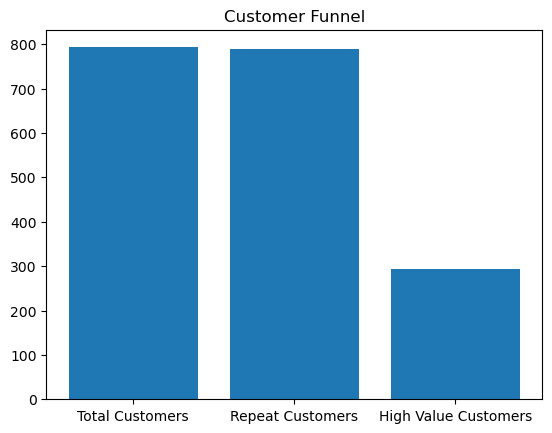

In [8]:
plt.bar(funnel["Stage"], funnel["Users"])
plt.title("Customer Funnel")
plt.show()